# Yuki — Anime Character Storyboard
Pure **pycairo** rendering. Proper capsule limbs, unified coat silhouette, chained skeleton joints. No generative AI.

In [1]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────
import cairo, math
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(42)

def surface_to_pil(surf):
    w,h=surf.get_width(),surf.get_height()
    buf=np.frombuffer(surf.get_data(),dtype=np.uint8).reshape(h,w,4).copy()
    buf[:,:,0],buf[:,:,2]=buf[:,:,2].copy(),buf[:,:,0].copy()   # BGRA→RGBA
    return Image.fromarray(buf,'RGBA')

def show(surf, title='', figsize=(7,6)):
    img=surface_to_pil(surf)
    fig,ax=plt.subplots(figsize=figsize); ax.imshow(img); ax.axis('off')
    if title: ax.set_title(title,fontsize=12,fontweight='bold',pad=8)
    plt.tight_layout(); plt.show()

print('pycairo', cairo.version)


pycairo 1.29.0


In [2]:
# ── Cell 2: Core drawing primitives ─────────────────────────────────────
def rgb(h):
    h=h.lstrip('#'); return tuple(int(h[i:i+2],16)/255 for i in (0,2,4))

INK=(0.07,0.05,0.03)

def capsule(ctx, x1,y1, x2,y2, r, fill, lw=2.2, outline=True):
    """Rounded-end capsule from (x1,y1) to (x2,y2) with radius r."""
    dx,dy=x2-x1,y2-y1; L=math.hypot(dx,dy)
    if L<0.5: disc(ctx,x1,y1,r,fill,lw,outline); return
    ang=math.atan2(dy,dx)
    ctx.save(); ctx.translate(x1,y1); ctx.rotate(ang)
    ctx.move_to(0,-r); ctx.arc(L,0,r,-math.pi/2,math.pi/2)
    ctx.arc(0,0,r,math.pi/2,-math.pi/2); ctx.close_path()
    ctx.set_source_rgb(*fill); ctx.fill_preserve()
    if outline:
        ctx.set_source_rgb(*INK); ctx.set_line_width(lw); ctx.stroke()
    else:
        ctx.new_path()
    ctx.restore()

def capsule_fill_only(ctx, x1,y1, x2,y2, r, fill):
    """Capsule without outline stroke — for seamless joins."""
    capsule(ctx,x1,y1,x2,y2,r,fill,outline=False)

def disc(ctx, x,y, r, fill, lw=2.0, outline=True):
    ctx.arc(x,y,r,0,2*math.pi); ctx.set_source_rgb(*fill); ctx.fill_preserve()
    if outline:
        ctx.set_source_rgb(*INK); ctx.set_line_width(lw); ctx.stroke()
    else:
        ctx.new_path()

def poly(ctx, pts, fill, lw=2.0):
    ctx.move_to(*pts[0])
    for p in pts[1:]: ctx.line_to(*p)
    ctx.close_path()
    ctx.set_source_rgb(*fill); ctx.fill_preserve()
    ctx.set_source_rgb(*INK); ctx.set_line_width(lw); ctx.stroke()

def seg(x,y, L, deg):
    """Endpoint of a segment from (x,y), length L, angle deg from vertical (down)."""
    r=math.radians(deg); return x+math.sin(r)*L, y+math.cos(r)*L

print('Primitives OK')


Primitives OK


In [3]:
# ── Cell 3: Colour palette ───────────────────────────────────────────────
C=dict(
    skin =rgb('#F2C49B'), skin_d=rgb('#D8A070'), skin_dd=rgb('#B87840'),
    hair =rgb('#4A2208'), hair_m=rgb('#6A3A18'), hair_hi=rgb('#8A5428'),
    iris =rgb('#22154A'), pupil=rgb('#070310'),  eye_w=rgb('#EEF2FF'),
    brow =rgb('#3A1808'), lip  =rgb('#C85858'),
    coat =rgb('#F2C50E'), coat_d=rgb('#C8A008'), coat_dd=rgb('#A08000'),
    shirt=rgb('#9ECDE8'), shirt_d=rgb('#70A8C8'),
    denim=rgb('#284870'), denim_l=rgb('#3A6098'),
    boot =rgb('#2E65A8'), boot_l=rgb('#5A95D8'), boot_d=rgb('#1A4580'),
    sock =rgb('#C0C0C0'), sock_d=rgb('#909090'),
)
print('Palette:', len(C), 'colours')


Palette: 23 colours


In [4]:
# ── Cell 4: Background helpers ───────────────────────────────────────────
def draw_sky(ctx,W,H,gy):
    tc,bc=rgb('#60AADC'),rgb('#C0E4F8')
    grad=cairo.LinearGradient(0,0,0,gy)
    grad.add_color_stop_rgb(0,*tc); grad.add_color_stop_rgb(1,*bc)
    ctx.rectangle(0,0,W,gy); ctx.set_source(grad); ctx.fill()

def draw_clouds(ctx,W,H,gy,rng):
    for cx2,cy2,sx,sy in [
        (W*0.12,H*0.12,65,32),(W*0.35,H*0.08,80,38),(W*0.62,H*0.13,70,30),(W*0.85,H*0.09,50,24)]:
        for dx,dy,fr in [(0,0,1.0),(sx*0.5,-sy*0.25,0.75),(-sx*0.45,-sy*0.20,0.70),(sx*0.22,sy*0.18,0.60)]:
            ctx.arc(cx2+dx,cy2+dy,fr*min(sx,sy)*0.55,0,2*math.pi)
            ctx.set_source_rgba(1,1,1,0.92); ctx.fill()

def draw_ground(ctx,W,H,gy):
    ctx.rectangle(0,gy,W,H-gy); ctx.set_source_rgb(*rgb('#8A6018')); ctx.fill()
    ctx.rectangle(0,gy-10,W,16); ctx.set_source_rgb(*rgb('#60B850')); ctx.fill()

def draw_grass(ctx,W,H,gy,rng):
    for _ in range(60):
        gx=rng.uniform(0,W); h=rng.uniform(14,38); w=rng.uniform(3,9)
        lean=rng.uniform(-8,8)
        gc=rgb('#52A840') if rng.random()>0.45 else rgb('#3D8A30')
        ctx.move_to(gx-w/2,gy)
        ctx.curve_to(gx-w/2,gy-h*0.4,gx+lean+w*0.3,gy-h*0.75,gx+lean,gy-h)
        ctx.curve_to(gx+lean-w*0.3,gy-h*0.75,gx+w/2,gy-h*0.4,gx+w/2,gy)
        ctx.close_path(); ctx.set_source_rgb(*gc); ctx.fill()

def draw_flower(ctx,fx,fy,size=22,color=None,rng=None):
    if color is None: color=C['skin']
    if rng is None: rng=np.random.default_rng(5)
    ctx.move_to(fx,fy)
    ctx.curve_to(fx+rng.uniform(-3,3),fy+size*0.8,fx+rng.uniform(-4,4),fy+size*1.6,fx+rng.uniform(-2,2),fy+size*1.9)
    ctx.set_source_rgb(*rgb('#4A8A30')); ctx.set_line_width(1.8); ctx.set_line_cap(cairo.LINE_CAP_ROUND); ctx.stroke()
    for i in range(5):
        a=i*2*math.pi/5-math.pi/2
        px,py=fx+math.cos(a)*size*1.2, fy+math.sin(a)*size*1.2
        ctx.save(); ctx.translate(fx,fy); ctx.rotate(a)
        ctx.scale(size*0.45,size*0.88); ctx.arc(0,1,1,0,2*math.pi); ctx.restore()
        ctx.set_source_rgba(*color,0.92); ctx.fill_preserve()
        ctx.set_source_rgba(*INK,0.35); ctx.set_line_width(0.8); ctx.stroke()
    ctx.arc(fx,fy,size*0.38,0,2*math.pi)
    ctx.set_source_rgb(*rgb('#F5D020')); ctx.fill_preserve()
    ctx.set_source_rgb(*INK); ctx.set_line_width(1.0); ctx.stroke()

def bg_scene(W,H,gy,seed=99):
    surf=cairo.ImageSurface(cairo.FORMAT_ARGB32,W,H)
    ctx=cairo.Context(surf); rng=np.random.default_rng(seed)
    draw_sky(ctx,W,H,gy); draw_clouds(ctx,W,H,gy,rng)
    draw_ground(ctx,W,H,gy); draw_grass(ctx,W,H,gy,rng)
    return surf,ctx

print('Background helpers OK')


Background helpers OK


In [5]:
# ── Cell 5: AnimeCharacter class ─────────────────────────────────────────
# Skeleton is a chain of joints. Pose = dict of joint angles (degrees from vertical).
# All segments drawn as capsules. Coat is a unified silhouette (no seam lines).

class AnimeCharacter:
    """
    Yuki — 8-year-old anime girl.
    draw(ctx, ox, oy, scale, pose) places feet at (ox, oy).
    pose keys: facing, l/r_upper_arm, l/r_lower_arm, l/r_upper_leg, l/r_lower_leg, crouch, head_tilt
    """
    def __init__(self,name='Yuki'): self.name=name

    def _pose(self,override):
        p=dict(facing='front',
               l_upper_arm=-8,l_lower_arm=5,r_upper_arm=8,r_lower_arm=-5,
               l_upper_leg=-3,l_lower_leg=2,r_upper_leg=3,r_lower_leg=-2,
               crouch=0.0, head_tilt=0)
        if override: p.update(override)
        return p

    def draw(self,ctx,ox,oy,scale=55,pose=None):
        p=self._pose(pose); s=scale; cr=p['crouch']

        # ── Proportions (in units, scaled by s) ──────────────────────────
        HR   = int(0.88*s)        # head radius
        NL   = int(0.32*s)        # neck length
        TH   = int(1.85*(1-0.18*cr)*s)  # torso height
        SHW  = int(1.10*s)        # shoulder half-width
        HHW  = int(0.60*s)        # hip half-width
        SLR  = int(0.40*s)        # sleeve radius
        SLL  = int(1.05*s)        # sleeve length
        FAL  = int(0.85*s)        # forearm length
        FAR  = int(0.22*s)        # forearm radius
        ULL  = int(1.55*(1-0.30*cr)*s)  # upper leg length
        ULR  = int(0.36*s)        # upper leg radius
        LLL  = int(1.38*(1-0.28*cr)*s)  # lower leg length
        LLR  = int(0.30*s)        # lower leg radius
        BOOR = int(0.33*s)        # boot radius
        BOOL = int(0.60*s)        # boot length

        # ── Skeleton joints (computed bottom-up from feet) ─────────────────
        ankle_y = oy - BOOL
        knee_y  = ankle_y - LLL
        hip_y   = knee_y  - ULL
        sho_y   = hip_y   - TH
        neck_y  = sho_y   + NL

        # Hip attachment points
        lhx,lhy = ox-int(HHW*0.55), hip_y
        rhx,rhy = ox+int(HHW*0.55), hip_y

        # Shoulder attachment points
        lsx,lsy = ox-SHW, sho_y
        rsx,rsy = ox+SHW, sho_y

        # ── Joint positions via chaining ──────────────────────────────────
        # left arm chain
        lel = seg(lsx,lsy, SLL, p['l_upper_arm'])
        lwt = seg(*lel, FAL, p['l_upper_arm']+p['l_lower_arm'])
        # right arm chain
        rel = seg(rsx,rsy, SLL, p['r_upper_arm'])
        rwt = seg(*rel, FAL, p['r_upper_arm']+p['r_lower_arm'])
        # left leg chain
        lkn = seg(lhx,lhy, ULL, p['l_upper_leg'])
        lan = seg(*lkn, LLL, p['l_upper_leg']+p['l_lower_leg'])
        lbt = seg(*lan, BOOL, p['l_upper_leg']+p['l_lower_leg'])  # boot bottom
        # right leg chain
        rkn = seg(rhx,rhy, ULL, p['r_upper_leg'])
        ran = seg(*rkn, LLL, p['r_upper_leg']+p['r_lower_leg'])
        rbt = seg(*ran, BOOL, p['r_upper_leg']+p['r_lower_leg'])

        facing=p['facing']; back=(facing=='back')

        # ── Draw order: back limbs → torso/coat → front limbs → head ───────
        # BACK LEG
        self._leg(ctx,lhx,lhy,lkn,lan,lan,lbt,ULR,LLR,BOOR,facing!='back')
        # BACK ARM (forearm only visible below sleeve)
        capsule(ctx,*lel,*lwt,FAR,C['skin'])
        disc(ctx,*lwt,int(FAR*0.88),C['skin'])

        # ── SHIRT (visible in coat gap) ─────────────────────────────────
        ctx.move_to(ox-int(SHW*0.28),sho_y)
        ctx.line_to(ox+int(SHW*0.28),sho_y)
        ctx.line_to(ox+int(HHW*0.35),hip_y+int(0.08*s))
        ctx.line_to(ox-int(HHW*0.35),hip_y+int(0.08*s))
        ctx.close_path(); ctx.set_source_rgb(*C['shirt']); ctx.fill()

        # ── COAT BODY (unified silhouette, fill then outline separately) ──
        bw=int(SHW*0.18); hw=int(HHW*0.15)  # extra width beyond shoulders/hips
        ctx.move_to(ox-SHW, sho_y)
        ctx.curve_to(ox-SHW-bw, sho_y+int(TH*0.25), ox-SHW-bw-int(0.10*s), hip_y-int(0.15*s), ox-SHW-int(0.08*s), hip_y+int(0.22*s))
        ctx.curve_to(ox-HHW-hw, hip_y+int(0.30*s), ox-int(SHW*0.22), hip_y+int(0.10*s), ox-int(SHW*0.22), hip_y+int(0.04*s))
        ctx.line_to(ox+int(SHW*0.22), hip_y+int(0.04*s))
        ctx.curve_to(ox+int(SHW*0.22), hip_y+int(0.10*s), ox+HHW+hw, hip_y+int(0.30*s), ox+SHW+int(0.08*s), hip_y+int(0.22*s))
        ctx.curve_to(ox+SHW+bw+int(0.10*s), hip_y-int(0.15*s), ox+SHW+bw, sho_y+int(TH*0.25), ox+SHW, sho_y)
        ctx.close_path()
        ctx.set_source_rgb(*C['coat']); ctx.fill()

        # Sleeves fill (no outline on attachment edge — seamless)
        capsule_fill_only(ctx,lsx,lsy,*lel,SLR,C['coat'])
        capsule_fill_only(ctx,rsx,rsy,*rel,SLR,C['coat'])

        # Now stroke the full coat outline
        ctx.move_to(ox-SHW, sho_y)
        ctx.curve_to(ox-SHW-bw, sho_y+int(TH*0.25), ox-SHW-bw-int(0.10*s), hip_y-int(0.15*s), ox-SHW-int(0.08*s), hip_y+int(0.22*s))
        ctx.curve_to(ox-HHW-hw, hip_y+int(0.30*s), ox-int(SHW*0.22), hip_y+int(0.10*s), ox-int(SHW*0.22), hip_y+int(0.04*s))
        ctx.line_to(ox+int(SHW*0.22), hip_y+int(0.04*s))
        ctx.curve_to(ox+int(SHW*0.22), hip_y+int(0.10*s), ox+HHW+hw, hip_y+int(0.30*s), ox+SHW+int(0.08*s), hip_y+int(0.22*s))
        ctx.curve_to(ox+SHW+bw+int(0.10*s), hip_y-int(0.15*s), ox+SHW+bw, sho_y+int(TH*0.25), ox+SHW, sho_y)
        ctx.close_path()
        ctx.set_source_rgb(*INK); ctx.set_line_width(2.2); ctx.stroke()

        for sx,sy,ex,ey in [(lsx,lsy,*lel),(rsx,rsy,*rel)]:
            dx,dy=ex-sx,ey-sy; L=math.hypot(dx,dy); ang=math.atan2(dy,dx); r=SLR
            ctx.save(); ctx.translate(sx,sy); ctx.rotate(ang)
            ctx.move_to(0,-r); ctx.arc(L,0,r,-math.pi/2,math.pi/2)
            ctx.line_to(0,r)
            ctx.set_source_rgb(*INK); ctx.set_line_width(2.2); ctx.stroke()
            ctx.restore()

        # Lapels
        lp_x=int(SHW*0.30)
        for sd in [-1,1]:
            ctx.move_to(ox+sd*lp_x, sho_y)
            ctx.curve_to(ox+sd*lp_x*1.5, sho_y+int(TH*0.25),
                         ox+sd*lp_x*1.4, hip_y-int(0.20*s),
                         ox+sd*int(SHW*0.26), hip_y+int(0.04*s))
            ctx.line_to(ox+sd*int(SHW*0.22), hip_y+int(0.04*s))
            ctx.close_path()
            ctx.set_source_rgb(*C['coat_d']); ctx.fill_preserve()
            ctx.set_source_rgb(*INK); ctx.set_line_width(1.0); ctx.stroke()

        # ── SHORTS ─────────────────────────────────────────────────────────
        sh=int(ULL*0.52)
        poly(ctx,[(lhx-int(ULR*0.4),lhy),(rhx+int(ULR*0.4),rhy),
                  (rhx+int(ULR*0.2),rhy+sh),(lhx-int(ULR*0.2),lhy+sh)],C['denim'])
        # highlight seam
        ctx.move_to(lhx+int(ULR*0.2),lhy+int(sh*0.2))
        ctx.curve_to(lhx+int(ULR*0.3),lhy+int(sh*0.6),ox-int(ULR*0.1),lhy+int(sh*0.72),ox,lhy+sh-2)
        ctx.set_source_rgb(*C['denim_l']); ctx.set_line_width(2); ctx.set_line_cap(cairo.LINE_CAP_ROUND); ctx.stroke()

        # ── FRONT LEG ──────────────────────────────────────────────────────
        self._leg(ctx,rhx,rhy,rkn,ran,ran,rbt,ULR,LLR,BOOR,facing!='back')

        # ── FRONT ARM ──────────────────────────────────────────────────────
        capsule(ctx,*rel,*rwt,FAR,C['skin'])
        disc(ctx,*rwt,int(FAR*0.88),C['skin'])

        # ── NECK ────────────────────────────────────────────────────────────
        capsule(ctx,ox,neck_y,ox,neck_y-NL,int(0.20*s),C['skin'],lw=1.8)

        # ── HEAD ────────────────────────────────────────────────────────────
        head_cy = neck_y - NL - HR + int(HR*0.15)
        self._head(ctx,ox,head_cy,HR,s,p,back)

    # ── Leg (upper leg + lower leg + sock band + boot) ────────────────────
    def _leg(self,ctx,hx,hy,kn,an,an2,bt,ULR,LLR,BOOR,show_boot=True):
        capsule(ctx,hx,hy,*kn,ULR,C['skin'])   # upper leg
        capsule(ctx,*kn,*an,LLR,C['skin'])      # lower leg
        # Knee cap (covers joint)
        disc(ctx,*kn,int(ULR*0.75),C['skin'],lw=1.5)
        # Sock band
        sx,sy=an
        capsule(ctx,sx,sy-int(LLR*0.4),sx,sy+int(LLR*0.5),int(BOOR*0.95),C['sock'],lw=1.8)
        # Boot
        capsule(ctx,*an,*bt,BOOR,C['boot'])
        # Boot shine
        bx1=an[0]+int(BOOR*0.30); by1=an[1]+int(BOOR*0.20)
        bx2=bt[0]+int(BOOR*0.25); by2=bt[1]-int(BOOR*0.25)
        ctx.move_to(bx1,by1); ctx.line_to(bx2,by2)
        ctx.set_source_rgb(*C['boot_l']); ctx.set_line_width(4)
        ctx.set_line_cap(cairo.LINE_CAP_ROUND); ctx.stroke()

    # ── Head ──────────────────────────────────────────────────────────────
    def _head(self,ctx,cx,cy,HR,s,p,back):
        ctx.save(); ctx.translate(cx,cy); ctx.rotate(math.radians(p['head_tilt']))

        # Face base
        disc(ctx,0,0,HR,C['skin'],lw=2.8)

        # Chin shadow
        grad=cairo.RadialGradient(0,HR*0.2,HR*0.1,0,HR*0.5,HR*1.2)
        grad.add_color_stop_rgba(0,*C['skin_d'],0); grad.add_color_stop_rgba(1,*C['skin_d'],0.22)
        ctx.arc(0,0,HR,0,2*math.pi); ctx.set_source(grad); ctx.fill()

        # Hair mass
        ctx.move_to(0,-HR-2)
        ctx.curve_to(HR*0.56,-HR*1.14, HR*1.20,-HR*0.55, HR*1.14,HR*0.32)
        ctx.curve_to(HR*1.02,HR*0.90,  HR*0.52,HR*1.10,  0,HR*1.14)
        ctx.curve_to(-HR*0.52,HR*1.10, -HR*1.02,HR*0.90, -HR*1.14,HR*0.32)
        ctx.curve_to(-HR*1.20,-HR*0.55,-HR*0.56,-HR*1.14, 0,-HR-2)
        ctx.set_source_rgb(*C['hair']); ctx.fill_preserve()
        ctx.set_source_rgb(*INK); ctx.set_line_width(2.2); ctx.stroke()

        # Fringe
        ctx.move_to(-HR*0.92,-HR*0.05)
        ctx.curve_to(-HR*0.82,-HR*0.64,-HR*0.32,-HR*0.74,-HR*0.08,-HR*0.52)
        ctx.curve_to( HR*0.08,-HR*0.38, HR*0.36,-HR*0.54, HR*0.62,-HR*0.70)
        ctx.curve_to( HR*0.82,-HR*0.62, HR*0.92,-HR*0.05, HR*0.92,-HR*0.05)
        ctx.curve_to( HR*0.62,-HR*0.22,-HR*0.62,-HR*0.22,-HR*0.92,-HR*0.05)
        ctx.close_path(); ctx.set_source_rgb(*C['hair']); ctx.fill()

        # Hair highlight
        ctx.move_to(HR*0.12,-HR*0.92)
        ctx.curve_to(HR*0.36,-HR*0.68,HR*0.30,-HR*0.32,HR*0.20,-HR*0.10)
        ctx.set_source_rgba(*C['hair_hi'],0.50); ctx.set_line_width(4)
        ctx.set_line_cap(cairo.LINE_CAP_ROUND); ctx.stroke()

        if not back:
            self._face(ctx,HR)
        ctx.restore()

    def _face(self,ctx,HR):
        # Eyes
        for s,xo in [(-1,-HR*0.34),(1,HR*0.34)]:
            ex,ey=xo,HR*0.10; ew,eh=HR*0.22,HR*0.28
            # Sclera
            ctx.save(); ctx.translate(ex,ey); ctx.scale(ew,eh)
            ctx.arc(0,0,1,0,2*math.pi); ctx.restore()
            ctx.set_source_rgb(*C['eye_w']); ctx.fill_preserve()
            ctx.set_source_rgb(*INK); ctx.set_line_width(1.5); ctx.stroke()
            # Iris
            ctx.save(); ctx.translate(ex+ew*0.06,ey+eh*0.10); ctx.scale(ew*0.66,eh*0.74)
            ctx.arc(0,0,1,0,2*math.pi); ctx.restore()
            ctx.set_source_rgb(*C['iris']); ctx.fill()
            # Iris sheen
            ig=cairo.RadialGradient(ex+ew*0.16,ey-eh*0.18,0, ex,ey+eh*0.10,eh*0.75)
            ig.add_color_stop_rgba(0,0.60,0.52,0.90,0.55); ig.add_color_stop_rgba(1,0,0,0,0)
            ctx.save(); ctx.translate(ex+ew*0.06,ey+eh*0.10); ctx.scale(ew*0.66,eh*0.74)
            ctx.arc(0,0,1,0,2*math.pi); ctx.restore()
            ctx.set_source(ig); ctx.fill()
            # Pupil
            ctx.arc(ex+ew*0.10,ey+eh*0.14,ew*0.28,0,2*math.pi)
            ctx.set_source_rgb(*C['pupil']); ctx.fill()
            # Catchlight
            ctx.arc(ex+ew*0.26,ey-eh*0.12,ew*0.13,0,2*math.pi)
            ctx.set_source_rgb(1,1,1); ctx.fill()
            ctx.arc(ex-ew*0.12,ey+eh*0.04,ew*0.07,0,2*math.pi)
            ctx.set_source_rgba(1,1,1,0.6); ctx.fill()
            # Upper lash
            ctx.save(); ctx.translate(ex,ey); ctx.scale(ew*1.06,eh*0.46)
            ctx.arc(0,-0.50,1,math.pi*1.06,math.pi*1.94); ctx.restore()
            ctx.set_source_rgb(*INK); ctx.set_line_width(2.5); ctx.stroke()
            # Brow
            boff=s*ew*0.52
            ctx.move_to(ex-s*ew*0.58,ey-eh*1.30)
            ctx.curve_to(ex,ey-eh*1.50, ex+boff,ey-eh*1.40, ex+boff,ey-eh*1.28)
            ctx.set_source_rgb(*C['brow']); ctx.set_line_width(2.6)
            ctx.set_line_cap(cairo.LINE_CAP_ROUND); ctx.stroke()
        # Nose
        ctx.arc(0,HR*0.40,HR*0.055,0,2*math.pi)
        ctx.set_source_rgba(*C['skin_d'],0.55); ctx.fill()
        # Mouth
        ctx.move_to(-HR*0.18,HR*0.64)
        ctx.curve_to(-HR*0.05,HR*0.76, HR*0.05,HR*0.76, HR*0.18,HR*0.64)
        ctx.set_source_rgb(*C['lip']); ctx.set_line_width(2.2)
        ctx.set_line_cap(cairo.LINE_CAP_ROUND); ctx.stroke()
        # Blush
        for bx in [-HR*0.56,HR*0.56]:
            bg=cairo.RadialGradient(bx,HR*0.40,0,bx,HR*0.40,HR*0.20)
            bg.add_color_stop_rgba(0,1,0.40,0.40,0.28)
            bg.add_color_stop_rgba(1,1,0.40,0.40,0)
            ctx.arc(bx,HR*0.40,HR*0.20,0,2*math.pi); ctx.set_source(bg); ctx.fill()

print('AnimeCharacter defined')


AnimeCharacter defined


In [6]:
# ── Cell 6: Instantiate the ONE persistent character ──────────────────────
yuki = AnimeCharacter('Yuki')
print(f'"{yuki.name}" ready — reused across all 4 scenes')


"Yuki" ready — reused across all 4 scenes


In [7]:
# ── Cell 7: Scene builder ─────────────────────────────────────────────────
W, H, GY = 720, 540, 388
SCENES = []   # collect rendered surfaces for storyboard

def render(title, fn, figsize=(8,6)):
    surf, ctx = bg_scene(W, H, GY)
    fn(ctx)
    SCENES.append(surf)
    show(surf, title, figsize)
    return surf

print('Scene builder ready')


Scene builder ready


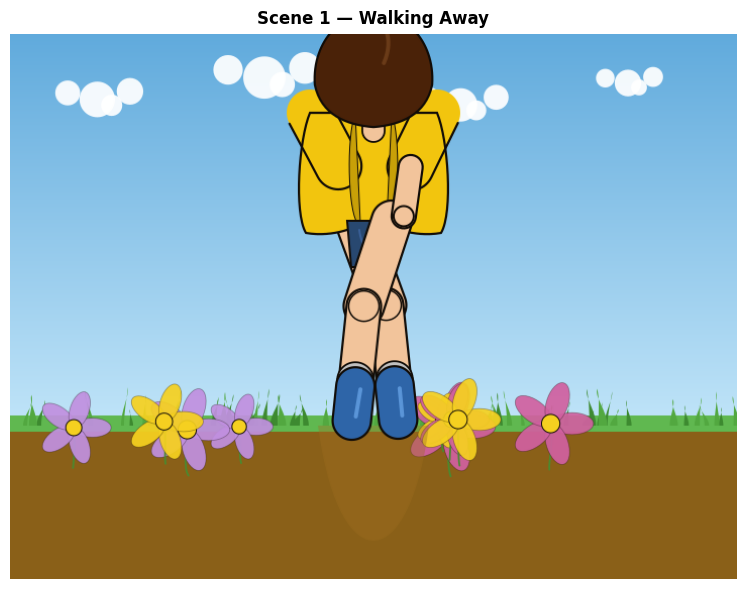

Scene 1 done


In [8]:
# ── Cell 8: Scene 1 — Walking Away ───────────────────────────────────────
def s1(ctx):
    rng=np.random.default_rng(7)
    fc=[C['skin'],rgb('#F5D020'),rgb('#D060A0'),rgb('#C090E0')]
    for _ in range(9):
        draw_flower(ctx,rng.uniform(60,W-60),GY+rng.integers(-6,5),
                    rng.integers(16,28),rng.choice(fc),rng)
    # Dirt path
    ctx.move_to(W//2-55,GY); ctx.curve_to(W//2-35,H,W//2+35,H,W//2+55,GY)
    ctx.close_path(); ctx.set_source_rgba(*rgb('#9E7020'),0.38); ctx.fill()

    yuki.draw(ctx, ox=W//2, oy=GY, scale=58,
              pose=dict(facing='back',
                        l_upper_leg=20,  l_lower_leg=-14,
                        r_upper_leg=-18, r_lower_leg=12,
                        l_upper_arm=28,  l_lower_arm=-20,
                        r_upper_arm=-26, r_lower_arm=18))

render('Scene 1 — Walking Away', s1)
print('Scene 1 done')


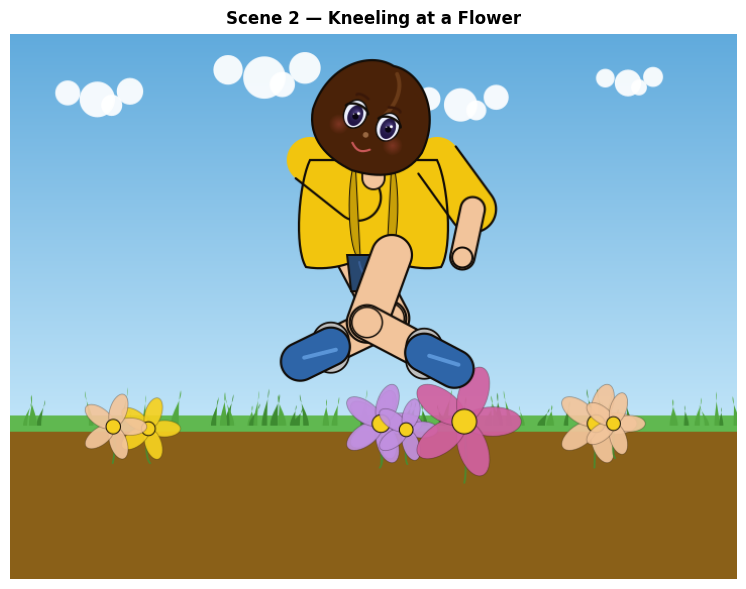

Scene 2 done


In [9]:
# ── Cell 9: Scene 2 — Kneeling at a Flower ───────────────────────────────
def s2(ctx):
    rng=np.random.default_rng(11)
    fc=[C['skin'],rgb('#F5D020'),rgb('#C090E0')]
    for _ in range(7):
        draw_flower(ctx,rng.uniform(60,W-60),GY+rng.integers(-5,6),
                    rng.integers(14,24),rng.choice(fc),rng)
    # Big flower she's looking at
    draw_flower(ctx,W//2+90,GY-4,32,rgb('#D060A0'))

    yuki.draw(ctx, ox=W//2, oy=GY, scale=58,
              pose=dict(facing='front',
                        crouch=0.68,
                        head_tilt=22,
                        l_upper_leg=28,  l_lower_leg=-92,
                        r_upper_leg=-20, r_lower_leg=82,
                        l_upper_arm=52,  l_lower_arm=-60,
                        r_upper_arm=36,  r_lower_arm=-48))

render('Scene 2 — Kneeling at a Flower', s2)
print('Scene 2 done')


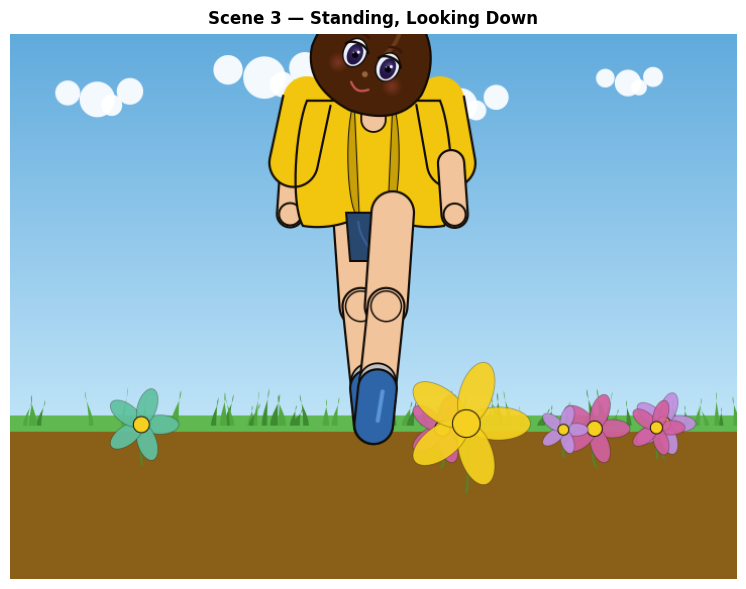

Scene 3 done


In [10]:
# ── Cell 10: Scene 3 — Standing, Looking Down ────────────────────────────
def s3(ctx):
    rng=np.random.default_rng(13)
    fc=[rgb('#D060A0'),rgb('#C090E0'),rgb('#60C0A0')]
    for _ in range(6):
        draw_flower(ctx,rng.uniform(60,W-60),GY+rng.integers(-5,5),
                    rng.integers(14,22),rng.choice(fc),rng)
    draw_flower(ctx,W//2+92,GY-2,36,rgb('#F5D020'))

    yuki.draw(ctx, ox=W//2, oy=GY, scale=60,
              pose=dict(facing='front',
                        head_tilt=24,
                        l_upper_arm=-12, l_lower_arm=8,
                        r_upper_arm=10,  r_lower_arm=-6,
                        l_upper_leg=4,   r_upper_leg=-4))

render('Scene 3 — Standing, Looking Down', s3)
print('Scene 3 done')


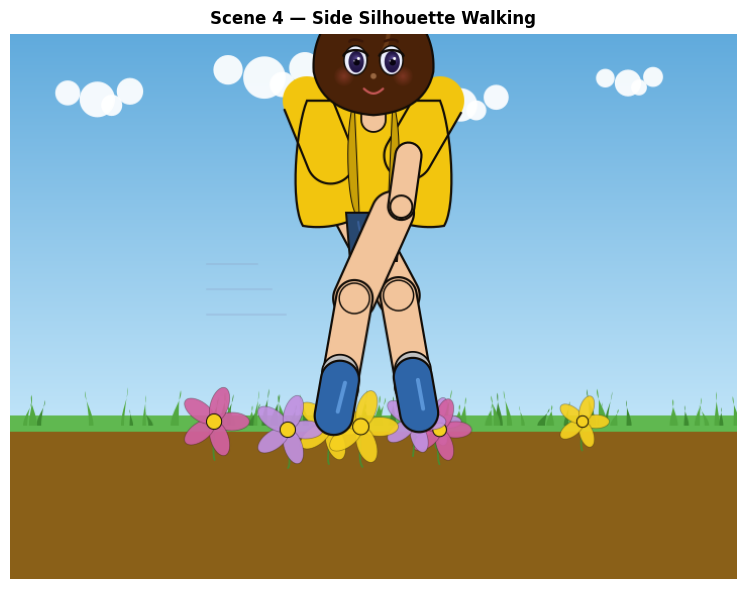

Scene 4 done


In [11]:
# ── Cell 11: Scene 4 — Side Silhouette Walking ───────────────────────────
def s4(ctx):
    rng=np.random.default_rng(17)
    fc=[rgb('#D060A0'),rgb('#F5D020'),rgb('#C090E0')]
    for _ in range(8):
        draw_flower(ctx,rng.uniform(60,W-60),GY+rng.integers(-5,5),
                    rng.integers(14,24),rng.choice(fc),rng)
    # Motion lines
    for i,ly in enumerate(range(GY-160,GY-85,25)):
        L=50+i*14
        ctx.move_to(W//2-165,ly); ctx.line_to(W//2-165+L,ly)
        ctx.set_source_rgba(*rgb('#90A8CC'),0.38); ctx.set_line_width(1.8)
        ctx.set_line_cap(cairo.LINE_CAP_ROUND); ctx.stroke()

    yuki.draw(ctx, ox=W//2, oy=GY, scale=60,
              pose=dict(facing='front',         # side view via arm/leg angles
                        l_upper_leg=28,  l_lower_leg=-18,
                        r_upper_leg=-24, r_lower_leg=14,
                        r_upper_arm=-30, r_lower_arm=22,
                        l_upper_arm=22,  l_lower_arm=-14))

render('Scene 4 — Side Silhouette Walking', s4)
print('Scene 4 done')


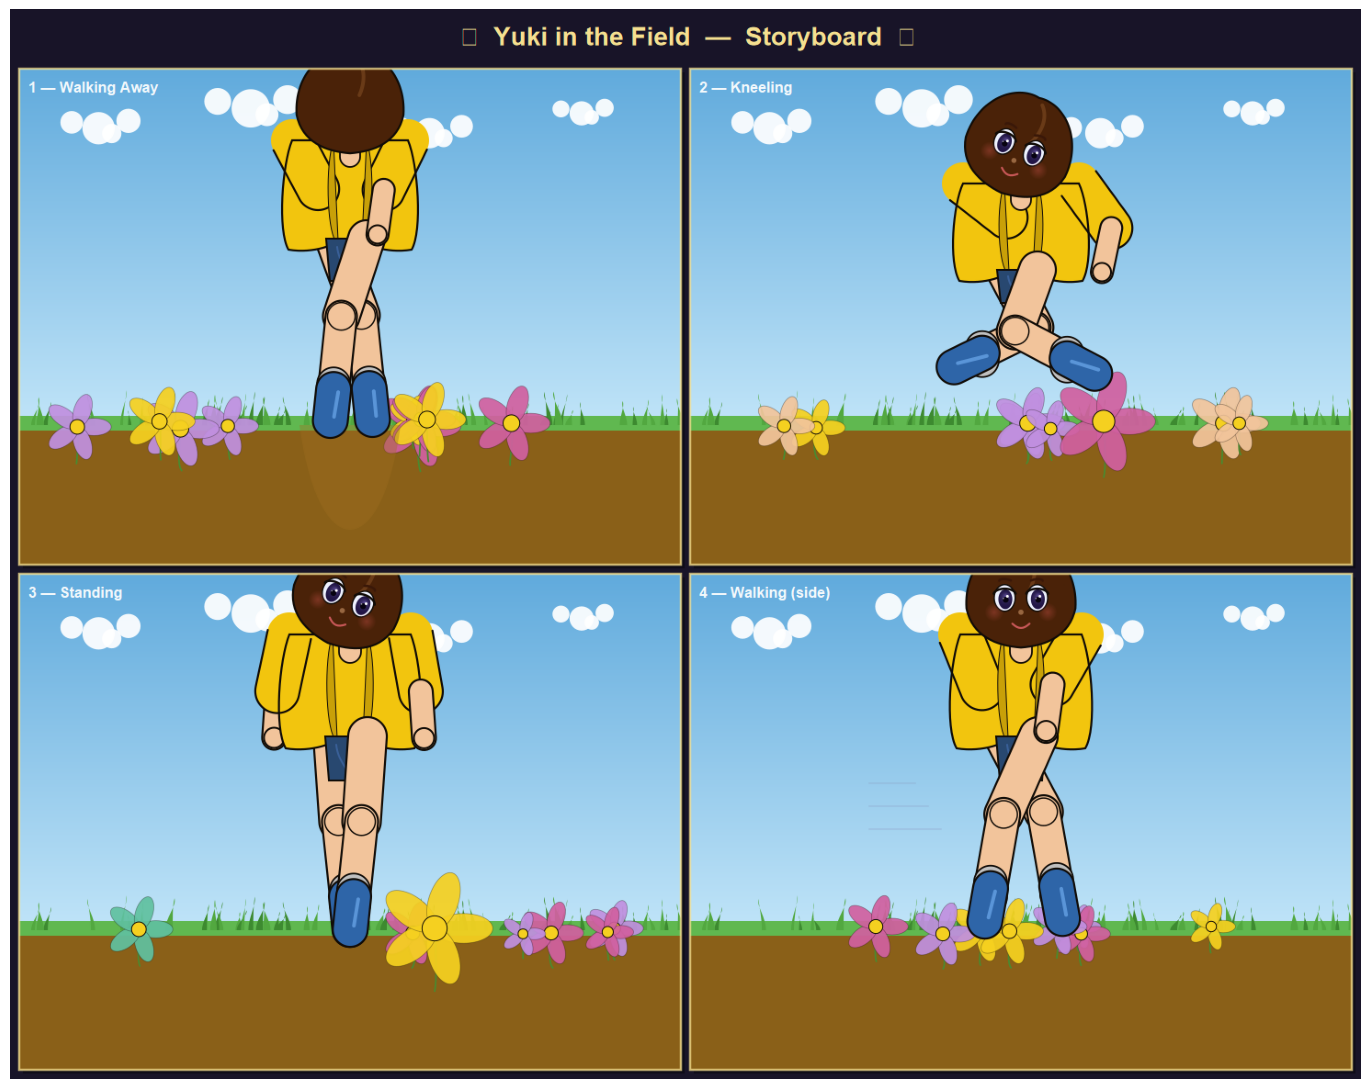

cairo.IOError: error while writing to output stream

In [12]:
# ── Cell 12: 2×2 Storyboard ──────────────────────────────────────────────
assert len(SCENES)==4, f'Need 4 scenes, have {len(SCENES)}'

BD=10; TH=55
BW=W*2+BD*3; BH=H*2+BD*3+TH

board=cairo.ImageSurface(cairo.FORMAT_ARGB32,BW,BH)
bctx=cairo.Context(board)

# Background
bctx.rectangle(0,0,BW,BH); bctx.set_source_rgb(*rgb('#181428')); bctx.fill()

# Title
bctx.select_font_face('Sans',cairo.FONT_SLANT_NORMAL,cairo.FONT_WEIGHT_BOLD)
bctx.set_font_size(28)
title='✦  Yuki in the Field  —  Storyboard  ✦'
te=bctx.text_extents(title)
bctx.move_to((BW-te.width)/2, TH*0.72)
bctx.set_source_rgb(*rgb('#F5E090')); bctx.show_text(title)

labels=['1 — Walking Away','2 — Kneeling','3 — Standing','4 — Walking (side)']
for i,(surf,lbl) in enumerate(zip(SCENES,labels)):
    row,col=i//2,i%2
    px=BD+col*(W+BD); py=TH+BD+row*(H+BD)
    # Shadow
    bctx.rectangle(px+4,py+4,W,H); bctx.set_source_rgba(0,0,0,0.40); bctx.fill()
    # Panel
    bctx.set_source_surface(surf,px,py); bctx.rectangle(px,py,W,H); bctx.fill()
    # Border
    bctx.rectangle(px,py,W,H); bctx.set_source_rgba(*rgb('#F5E090'),0.75)
    bctx.set_line_width(2.5); bctx.stroke()
    # Label
    bctx.select_font_face('Sans',cairo.FONT_SLANT_NORMAL,cairo.FONT_WEIGHT_BOLD)
    bctx.set_font_size(16); bctx.move_to(px+10,py+26)
    bctx.set_source_rgba(1,1,1,0.92); bctx.show_text(lbl)

show(board,'',figsize=(14,11))
board.write_to_png('/tmp/storyboard.png')
print('Storyboard saved')
